In [ ]:
!python -m venv .venv
!.venv/bin/python -m pip install --upgrade pip
!.venv/bin/python -m pip install gen3_validator
!.venv/bin/python -m pip install ipykernel
!.venv/bin/python -m pip install matplotlib pandas
!.venv/bin/python -m ipykernel install --user --name gen3-validator --display-name "gen3_kernal"

# ACDC minimal analysis

A deliberately small companion to `pipeline.py`: pulls **one
cohort** from Gen3, flattens it to one row per subject, and renders
just two plots — a boxplot of baseline age by sex, and a scatter of
BMI vs systolic blood pressure. Useful as a fast starting point for
ad-hoc exploration.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from gen3_metadata.gen3_metadata_parser import fetch_all_metadata

In [ ]:
KEY_FILE = "/Users/harrijh/keys/acdc_api_key_staging.json"
PROGRAM = "program1"
STUDY_ID = "CDAH"

In [ ]:
# ---- Flatten helpers (mirrors pipeline.py to keep this notebook
# self-contained — no cross-file imports from scripts/). ----

LEAF_NODES = (
    "demographic",
    "medical_history",
    "blood_pressure_test",
    "exposure",
    "lab_result",
    "medication",
)
DROP_COMMON = (
    "project_id",
    "data_release",
    "data_release_date",
    "id",
    "type",
)

def fk_submitter_id(value):
    """Extract submitter_id from a Gen3 FK column ([{'submitter_id': ...}, ...])."""
    if isinstance(value, list) and value:
        return value[0].get("submitter_id")
    if isinstance(value, dict):
        return value.get("submitter_id")
    return None

def _slim(df, fk_col, link_col, node_name):
    """Return leaf node with FK extracted, common cols dropped, and node-prefixed columns."""
    df = df.copy()
    df[link_col] = df[fk_col].apply(fk_submitter_id)
    drop = [c for c in list(DROP_COMMON) + [fk_col] if c in df.columns]
    df = df.drop(columns=drop)
    rename = {c: f"{node_name}__{c}" for c in df.columns if c not in (link_col,)}
    rename["submitter_id"] = f"{node_name}_submitter_id"
    df = df.rename(
        columns={**rename, "submitter_id": f"{node_name}_submitter_id"}
    )
    if f"{node_name}__submitter_id" in df.columns:
        df = df.rename(
            columns={f"{node_name}__submitter_id": f"{node_name}_submitter_id"}
        )
    return df

def flatten(dfs):
    """Join subject ← clinical_descriptor (baseline) ← leaf nodes into one wide frame."""
    subject = (
        getattr(dfs, "subject")
        .copy()
        .rename(columns={"submitter_id": "subject_submitter_id"})
    )

    cd = getattr(dfs, "clinical_descriptor").copy()
    if "baseline_measure" in cd.columns:
        cd = cd[cd["baseline_measure"] == True]  # noqa: E712
    cd["subject_submitter_id"] = cd["subjects"].apply(fk_submitter_id)
    cd = cd.drop(
        columns=[c for c in list(DROP_COMMON) + ["subjects"] if c in cd.columns]
    )
    cd = cd.rename(columns={"submitter_id": "clinical_descriptor_submitter_id"})

    flat = subject.merge(cd, on="subject_submitter_id", how="left")
    for node in LEAF_NODES:
        leaf = getattr(dfs, node)
        if leaf.empty:
            continue
        slim = _slim(
            leaf,
            "clinical_descriptors",
            "clinical_descriptor_submitter_id",
            node,
        )
        flat = flat.merge(
            slim, on="clinical_descriptor_submitter_id", how="left"
        )
    return flat

In [ ]:
result = fetch_all_metadata(KEY_FILE, PROGRAM, STUDY_ID)
df = flatten(result.to_df())
mo.md(f"**{STUDY_ID}**: {df.shape[0]:,} subjects × {df.shape[1]} columns")

fetch_all_metadata: starting for program1/CDAH
fetch_all_metadata: fetching data dictionary from cad.staging.biocommons.org.au...
fetch_all_metadata: 29 nodes to fetch
  [1/29] fetching 'program'...
  [1/29] program: OK (0 records)
  [2/29] fetching 'project'...
  [2/29] project: OK (0 records)
  [3/29] fetching 'acknowledgement'...
  [3/29] acknowledgement: OK (0 records)
  [4/29] fetching 'publication'...
  [4/29] publication: OK (0 records)
  [5/29] fetching 'subject'...
  [5/29] subject: OK (7930 records)
node 'subject': selected data_release_date=2026-04-10 data_release='1.0.1' (3965/7930 records)
  [5/29] subject: filtered to 3965/7930 records (data_release='latest')
  [6/29] fetching 'clinical_descriptor'...
  [6/29] clinical_descriptor: OK (7930 records)
node 'clinical_descriptor': selected data_release_date=2026-04-10 data_release='1.0.1' (3965/7930 records)
  [6/29] clinical_descriptor: filtered to 3965/7930 records (data_release='latest')
  [7/29] fetching 'data_release'...


<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>CDAH</strong>: 3,965 subjects × 51 columns</span></span>

## Boxplot — baseline age by sex

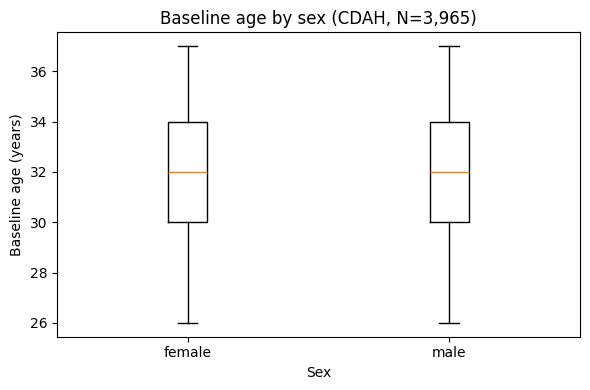

In [ ]:
age_col = "demographic__baseline_age"
sex_col = "demographic__sex"

box_df = df[[age_col, sex_col]].copy()
box_df[age_col] = pd.to_numeric(box_df[age_col], errors="coerce")
box_df = box_df.dropna(subset=[age_col, sex_col])

levels = sorted(box_df[sex_col].unique())
data = [box_df.loc[box_df[sex_col] == lvl, age_col].values for lvl in levels]

fig_box, ax_box = plt.subplots(figsize=(6, 4))
ax_box.boxplot(data, tick_labels=levels)
ax_box.set_xlabel("Sex")
ax_box.set_ylabel("Baseline age (years)")
ax_box.set_title(f"Baseline age by sex (CDAH, N={len(box_df):,})")
fig_box.tight_layout()
fig_box

## Scatter — BMI vs systolic blood pressure

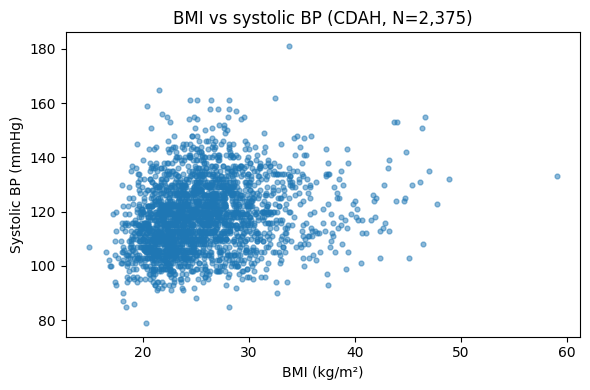

In [ ]:
bmi_col = "demographic__bmi_baseline"
sbp_col = "blood_pressure_test__bp_systolic"

sc_df = df[[bmi_col, sbp_col]].copy()
sc_df[bmi_col] = pd.to_numeric(sc_df[bmi_col], errors="coerce")
sc_df[sbp_col] = pd.to_numeric(sc_df[sbp_col], errors="coerce")
sc_df = sc_df.dropna()

fig_sc, ax_sc = plt.subplots(figsize=(6, 4))
ax_sc.scatter(sc_df[bmi_col], sc_df[sbp_col], alpha=0.5, s=12)
ax_sc.set_xlabel("BMI (kg/m²)")
ax_sc.set_ylabel("Systolic BP (mmHg)")
ax_sc.set_title(f"BMI vs systolic BP (CDAH, N={len(sc_df):,})")
fig_sc.tight_layout()
fig_sc